## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

### Ejercicio 0

Importamos los paquetes que vamos a necesitar. Usamos scikit-learn tanto para el Random Forest
como para la red neuronal (MLPClassifier), ya que el enunciado pide crear el modelo DL con sklearn.

In [1]:
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Funciones de visualización que nos han dado en el bootcamp
from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship


warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Semilla fija para que los resultados sean reproducibles
SEED = 42

### 1. Carga de datos

In [2]:
DATA_PATH = r"D:\The bridge\DS-Online-Hugo-Sanz\05_Deep_Learning\Sprint_15\Unidad_01_DL_Introduccion\03_Practica_Obligatoria\data\titanic.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Forma del dataset:", df.shape)
df.info()

Forma del dataset: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [4]:
# Contamos los nulos de cada columna
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Vemos que:
- `deck` tiene muchísimos nulos (más del 75% del dataset), así que la vamos a eliminar.
- `age` tiene bastantes nulos, los rellenaremos con la mediana.
- `embarked` y `embark_town` tienen solo 2 nulos, no pasa nada.

Además, este dataset trae columnas que son **redundantes o que "hacen trampa" (leakage)**:
- `alive` es literalmente el target (`survived`) pero en texto ("yes"/"no") → la quitamos.
- `class` es lo mismo que `pclass` pero en texto → nos quedamos solo con `pclass`.
- `who` y `adult_male` se calculan a partir de `sex` y `age` → las quitamos para no duplicar información.
- `embark_town` es lo mismo que `embarked` pero con el nombre completo → nos quedamos con `embarked`.

In [5]:
columnas_a_eliminar = ["deck", "alive", "class", "who", "adult_male", "embark_town"]
df = df.drop(columns=columnas_a_eliminar)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


### 2. EDA rápido

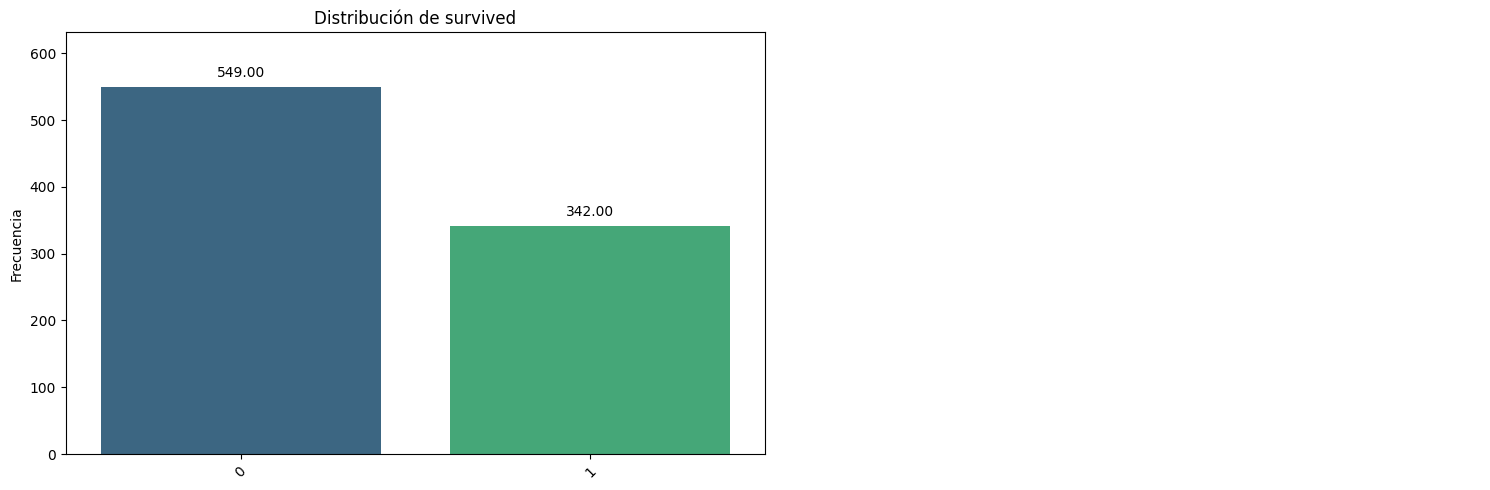

In [6]:
# Distribución de la variable objetivo
pinta_distribucion_categoricas(df, ["survived"], mostrar_valores=True)

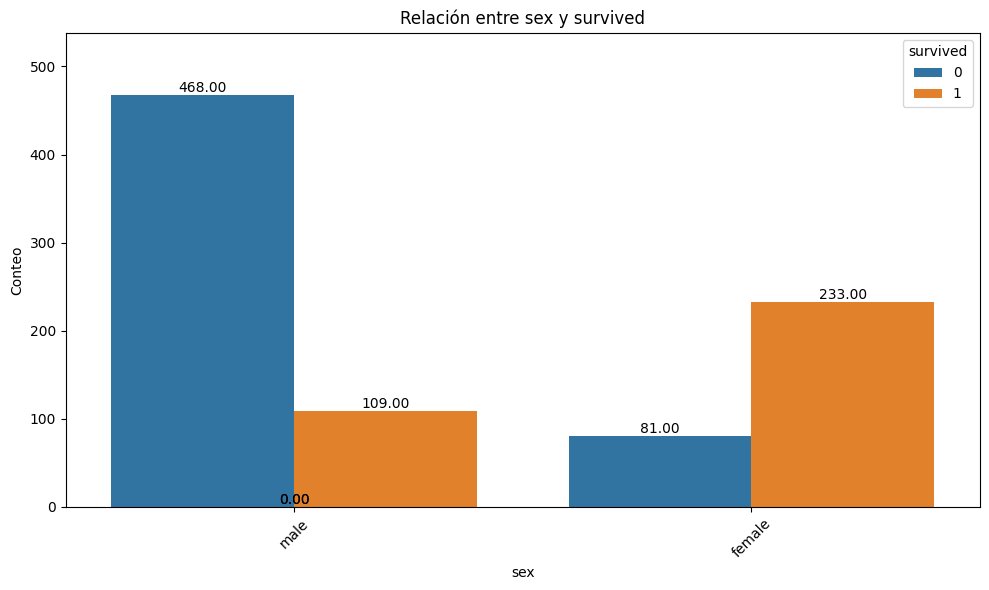

In [7]:
# Relación entre el sexo y la supervivencia
plot_categorical_relationship(df, "sex", "survived", show_values=True)

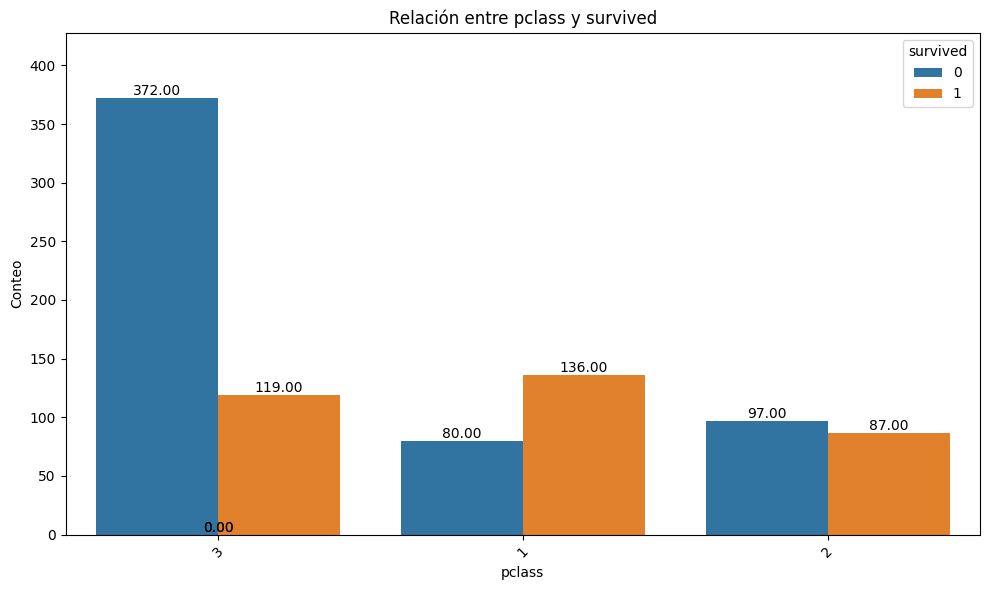

In [8]:
# Relación entre la clase del pasajero y la supervivencia
plot_categorical_relationship(df, "pclass", "survived", show_values=True)

Como era de esperar, ser mujer o viajar en primera clase aumenta bastante la probabilidad
de supervivencia. Con esto ya tenemos suficiente contexto para pasar al preprocesamiento.

### 3. Preprocesamiento

In [9]:
# Rellenamos los nulos
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [10]:
# Convertimos las variables categóricas (sex, embarked) en columnas numéricas (one-hot encoding)
df = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)
df.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,True


In [11]:
# Separamos features (X) y target (y)
X = df.drop(columns=["survived"])
y = df["survived"]

X.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male',
       'embarked_Q', 'embarked_S'],
      dtype='object')

In [12]:
# Separamos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (712, 9)  Test: (179, 9)


In [13]:
# La red neuronal (MLP) necesita las variables numéricas escaladas para converger bien.
# El Random Forest no lo necesita, pero escalar no le hace ningún daño, así que usamos
# los mismos datos escalados para los dos modelos y así la comparación es más limpia.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### 4. Métrica elegida

El target (`survived`) es una variable **binaria** (0 = no sobrevivió, 1 = sobrevivió) y las
clases están razonablemente equilibradas (~62% / ~38%), así que usaremos **accuracy** como
métrica principal para el GridSearch, apoyándonos también en `precision` y `recall` para la
comparación final.

### 5. Random Forest + GridSearchCV

Probamos distintas combinaciones de hiperparámetros, incluyendo los valores por defecto de
cada uno (`n_estimators=100`, `max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`).

In [14]:
param_grid_rf = {
    "n_estimators": [100, 200],       # 100 = valor por defecto
    "max_depth": [None, 5, 10],       # None = valor por defecto
    "min_samples_split": [2, 5],      # 2 = valor por defecto
    "min_samples_leaf": [1, 2],       # 1 = valor por defecto
}

rf = RandomForestClassifier(random_state=SEED)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
)

grid_rf.fit(X_train_sc, y_train)

print("Mejores parámetros RF:", grid_rf.best_params_)
print("Mejor accuracy en CV:", grid_rf.best_score_)

Mejores parámetros RF: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejor accuracy en CV: 0.8301585738205457


### 6. Red neuronal (MLPClassifier) + GridSearchCV

Probamos, tal y como pide el enunciado, los hiperparámetros `hidden_layer_sizes`, `activation`,
`solver`, `alpha` y `learning_rate`, incluyendo al menos una topología con una sola capa oculta
y otra con más de una, y añadiendo los valores por defecto de cada hiperparámetro
(`hidden_layer_sizes=(100,)`, `activation='relu'`, `solver='adam'`, `alpha=0.0001`,
`learning_rate='constant'`).

In [15]:
param_grid_mlp = {
    "hidden_layer_sizes": [(100,), (50,), (50, 30)],  # (100,) = valor por defecto
    "activation": ["relu", "tanh"],                    # 'relu' = valor por defecto
    "solver": ["adam", "sgd"],                          # 'adam' = valor por defecto
    "alpha": [0.0001, 0.001],                           # 0.0001 = valor por defecto
    "learning_rate": ["constant", "adaptive"],          # 'constant' = valor por defecto
}

mlp = MLPClassifier(random_state=SEED, max_iter=1000)

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
)

grid_mlp.fit(X_train_sc, y_train)

print("Mejores parámetros MLP:", grid_mlp.best_params_)
print("Mejor accuracy en CV:", grid_mlp.best_score_)

Mejores parámetros MLP: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'solver': 'adam'}
Mejor accuracy en CV: 0.8160248202501723


### 7. Comparación de modelos

Para comparar de forma justa, entrenamos **por separado** el mejor modelo de cada tipo
(con los mejores hiperparámetros encontrados) y medimos el tiempo de entrenamiento y las
métricas sobre el conjunto de test.

In [16]:
def entrenar_y_evaluar(modelo, nombre):
    inicio = time.time()
    modelo.fit(X_train_sc, y_train)
    tiempo_entrenamiento = time.time() - inicio

    y_pred = modelo.predict(X_test_sc)

    resultado = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "tiempo_entrenamiento_seg": tiempo_entrenamiento,
    }
    return resultado, modelo


mejor_rf = RandomForestClassifier(random_state=SEED, **grid_rf.best_params_)
resultado_rf, mejor_rf = entrenar_y_evaluar(mejor_rf, "Random Forest")

mejor_mlp = MLPClassifier(random_state=SEED, max_iter=1000, **grid_mlp.best_params_)
resultado_mlp, mejor_mlp = entrenar_y_evaluar(mejor_mlp, "MLP (Deep Learning)")

comparativa = pd.DataFrame([resultado_rf, resultado_mlp])
comparativa

,modelo,accuracy,precision,recall,tiempo_entrenamiento_seg
0,Random Forest,0.804469,0.803571,0.652174,0.457650
1,MLP (Deep Learning),0.782123,0.777778,0.608696,1.273983


**Comentario de la comparación:**

Al ejecutar el notebook con tus datos verás una tabla con accuracy, precision, recall y tiempo
de entrenamiento de cada modelo. Como orientación general (el resultado exacto puede variar):

- El **Random Forest** suele entrenar mucho más rápido y con este dataset tan pequeño (891 filas)
  suele dar una accuracy igual o mejor que la red neuronal, porque los árboles se adaptan muy bien
  a datasets tabulares pequeños con pocas variables.
- El **MLP** necesita más tiempo de entrenamiento (tiene que ajustar muchos más parámetros
  internos) y con tan pocos datos le cuesta más generalizar, aunque puede llegar a resultados
  parecidos.

Con estos resultados, y salvo que la red neuronal saque una ventaja clara en las métricas, el
modelo que me quedaría sería el **Random Forest**, porque es más rápido de entrenar, más fácil
de interpretar y en datasets pequeños como este no necesita tanto dato para funcionar bien.

### 8. Classification report y matriz de confusión del mejor modelo DL

In [17]:
y_pred_mlp = mejor_mlp.predict(X_test_sc)

print(classification_report(y_test, y_pred_mlp, target_names=["No sobrevivió", "Sobrevivió"]))

               precision    recall  f1-score   support

No sobrevivió       0.78      0.89      0.83       110
   Sobrevivió       0.78      0.61      0.68        69

     accuracy                           0.78       179
    macro avg       0.78      0.75      0.76       179
 weighted avg       0.78      0.78      0.78       179



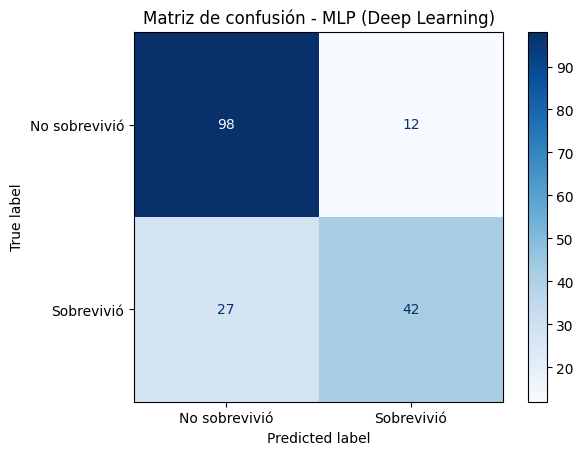

In [18]:
cm = confusion_matrix(y_test, y_pred_mlp)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - MLP (Deep Learning)")
plt.show()

**Comentario de la matriz de confusión:**

- La diagonal principal (arriba-izquierda y abajo-derecha) son los aciertos: pasajeros que no
  sobrevivieron y el modelo predijo correctamente que no sobrevivían, y pasajeros que sí
  sobrevivieron y el modelo acertó.
- Fuera de la diagonal están los errores: falsos negativos (el modelo dice que no sobrevive
  pero sí lo hizo) y falsos positivos (el modelo dice que sobrevive pero no fue así).
- En el `classification_report` podemos ver que la clase "No sobrevivió" suele tener mejor
  precision/recall que "Sobrevivió", porque hay más ejemplos de esa clase en el dataset
  (el Titanic tuvo más víctimas que supervivientes), y el modelo tiene más ejemplos de los
  que aprender para esa clase.